In [1]:
# Imports y utilidades centralizadas
import sys
sys.path.insert(0, '../utils')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from funciones import limpiar_nombres_columnas, anonimizar

In [2]:
# Carga de datos (skiprows=1 porque los CSV traen una fila de título arriba)
df_ventas   = pd.read_csv('../data/informe_ventas.csv',   skiprows=1)
df_reservas = pd.read_csv('../data/informe_reservas.csv', skiprows=1)

# Normalización de nombres de columnas
df_ventas   = limpiar_nombres_columnas(df_ventas)
df_reservas = limpiar_nombres_columnas(df_reservas)

# Verificación rápida
print("Columnas en ventas:  ", df_ventas.columns.tolist())
print("Columnas en reservas:", df_reservas.columns.tolist())

Columnas en ventas:   ['producto', 'mes_del_pago', 'creado_el', 'tipo_de_pago', 'codigo_postal_de_tarjeta_de_credito', 'cargo_de_gestion', 'neto', 'id_de_reserva', 'reprogramacion', 'pais_del_telefono', 'email']
Columnas en reservas: ['mes_de_la_disponibilidad', 'producto', 'id_de_reserva', 'reprogramacion', 'email', 'nº_de_pax', 'cargos_de_gestion', 'total_pagado_tras_cargos_de_procesamiento']


In [3]:
# Anonimización
# email -> cliente_id (entero) | CP -> cp_area (3 dígitos, solo provincias ES válidas)
df_ventas, df_reservas = anonimizar(df_ventas, df_reservas)
print("Anonimización aplicada. Columnas df_ventas:", df_ventas.columns.tolist())

Anonimización aplicada. Columnas df_ventas: ['producto', 'mes_del_pago', 'creado_el', 'tipo_de_pago', 'cargo_de_gestion', 'neto', 'id_de_reserva', 'reprogramacion', 'pais_del_telefono', 'cliente_id', 'cp_area']


## Verificación de H4 — Retención vs. Cross-selling

**Hipótesis:** la base de clientes recurrentes se inclina más hacia la **repetición del mismo servicio** que hacia el **cross-selling** (probar productos nuevos).

**Criterio de verificación:**
1. Clasificar cada cliente único en una de tres categorías según su comportamiento:
   - **Ocasional**: 1 sola visita.
   - **Leal (repite mismo servicio)**: >1 visita, todas al mismo producto.
   - **Cross-selling (varios servicios)**: >1 visita y >1 producto distinto.
2. Medir el reparto en términos absolutos y porcentuales.
3. **Sobre los clientes recurrentes** (>1 visita) calcular el ratio Leales vs. Cross-selling — es la métrica que responde directamente a la hipótesis.

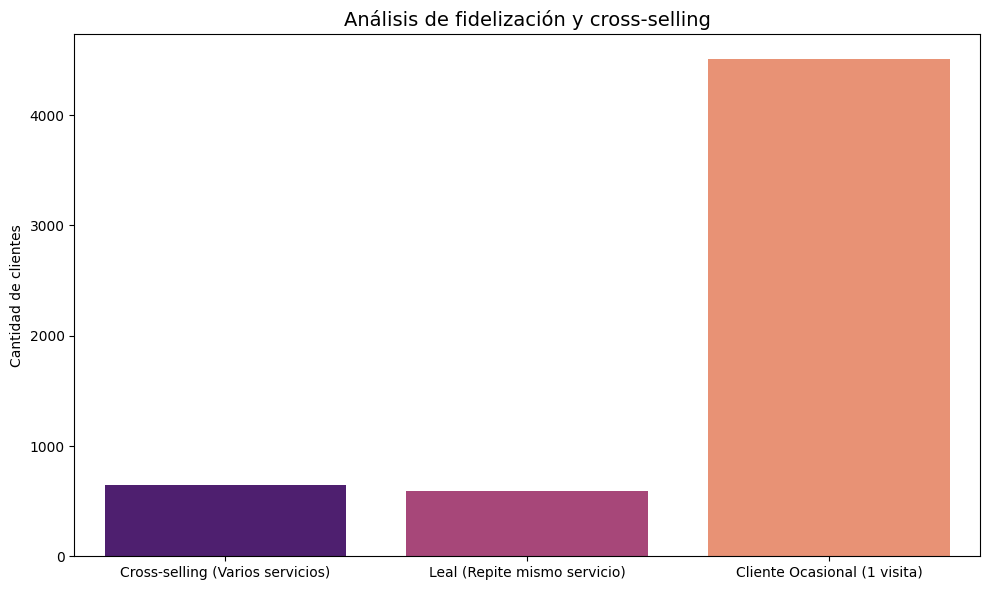

In [4]:
# Perfil de cliente: nº de servicios distintos y nº de visitas totales
perfil_cliente = (df_ventas.groupby('cliente_id')
                           .agg(servicios_distintos=('producto', 'nunique'),
                                visitas_totales=('neto', 'count')))

# Lógica de comportamiento (3 buckets exclusivos)
def definir_perfil(row):
    if row['visitas_totales'] > 1:
        if row['servicios_distintos'] > 1:
            return 'Cross-selling (Varios servicios)'
        return 'Leal (Repite mismo servicio)'
    return 'Cliente Ocasional (1 visita)'

perfil_cliente['categoria'] = perfil_cliente.apply(definir_perfil, axis=1)

# Visualización del embudo de retención
plt.figure(figsize=(10, 6))
sns.countplot(data=perfil_cliente, x='categoria',
              palette='magma', hue='categoria', legend=False)
plt.title('Análisis de fidelización y cross-selling', fontsize=14)
plt.ylabel('Cantidad de clientes')
plt.xlabel('')
plt.tight_layout()
plt.savefig('../img/04_analisis_retencion.png', dpi=200)
plt.show()

=== Reparto sobre el TOTAL de clientes únicos ===
  Cliente Ocasional (1 visita)             4,508  (78.5%)
  Cross-selling (Varios servicios)           643  (11.2%)
  Leal (Repite mismo servicio)               595  (10.4%)
  TOTAL                                    5,746

=== Entre los 1,238 clientes recurrentes (>1 visita) ===
  Leales (mismo servicio):         595  (48.1%)
  Cross-selling (varios):          643  (51.9%)
  Mediana de visitas:             2
  Mediana de servicios distintos: 2
  Ratio cross-selling / leal:     1.08


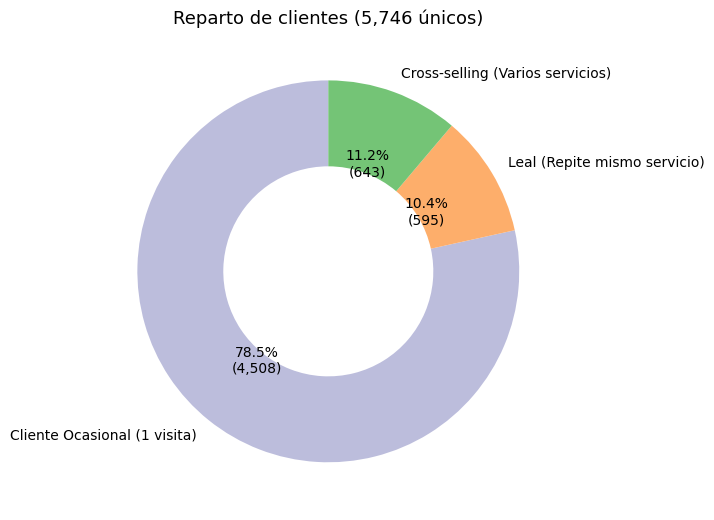

In [5]:
# Cuantificación detallada para el veredicto
total_clientes = len(perfil_cliente)
counts = perfil_cliente['categoria'].value_counts()
pcts   = (counts / total_clientes * 100).round(1)

print("=== Reparto sobre el TOTAL de clientes únicos ===")
for cat in counts.index:
    print(f"  {cat:40s} {counts[cat]:>5,}  ({pcts[cat]:.1f}%)")
print(f"  {'TOTAL':40s} {total_clientes:>5,}")
print()

# Sobre clientes RECURRENTES
recurrentes = perfil_cliente[perfil_cliente['visitas_totales'] > 1]
n_leal  = (recurrentes['categoria'] == 'Leal (Repite mismo servicio)').sum()
n_cross = (recurrentes['categoria'] == 'Cross-selling (Varios servicios)').sum()
n_rec   = len(recurrentes)

print(f"=== Entre los {n_rec:,} clientes recurrentes (>1 visita) ===")
print(f"  Leales (mismo servicio):        {n_leal:>4,}  ({n_leal/n_rec*100:.1f}%)")
print(f"  Cross-selling (varios):         {n_cross:>4,}  ({n_cross/n_rec*100:.1f}%)")
print(f"  Mediana de visitas:             {recurrentes['visitas_totales'].median():.0f}")
print(f"  Mediana de servicios distintos: {recurrentes['servicios_distintos'].median():.0f}")
print(f"  Ratio cross-selling / leal:     {n_cross/n_leal:.2f}")

# Donut con reparto y porcentajes
plt.figure(figsize=(7, 7))
colores = ['#bcbddc', '#fdae6b', '#74c476']
orden = ['Cliente Ocasional (1 visita)',
         'Leal (Repite mismo servicio)',
         'Cross-selling (Varios servicios)']
counts_ord = counts.reindex(orden)
plt.pie(counts_ord, labels=counts_ord.index,
        autopct=lambda p: f'{p:.1f}%\n({int(round(p*total_clientes/100)):,})',
        colors=colores, startangle=90, wedgeprops=dict(width=0.45))
plt.title(f'Reparto de clientes ({total_clientes:,} únicos)', fontsize=13)
plt.tight_layout()
plt.savefig('../img/04_reparto_clientes.png', dpi=200)
plt.show()

### Veredicto H4 — **REFUTADA** (el cross-selling gana ligeramente, pero el hallazgo dominante es otro)

**Resumen cuantitativo (5.746 clientes únicos):**

| Categoría | Clientes | % del total |
|---|---:|---:|
| Ocasional (1 visita) | **4.508** | **78,5 %** |
| Cross-selling (varios servicios) | 643 | 11,2 % |
| Leal (repite mismo servicio) | 595 | 10,4 % |

**Entre los 1.238 clientes recurrentes (>1 visita):**

| | Clientes | % de recurrentes |
|---|---:|---:|
| **Cross-selling** | **643** | **51,9 %** |
| Leal (repite mismo) | 595 | 48,1 % |
| Mediana de visitas | 2 | — |
| Mediana de servicios distintos | 2 | — |

**Interpretación:**

1. **La hipótesis se refuta:** entre los clientes recurrentes el cross-selling (51,9 %) supera ligeramente a la repetición del mismo servicio (48,1 %). El cliente del Oasis Spa que repite tiende **levemente** a **explorar** distintos productos antes que a quedarse con uno.
2. **El hallazgo realmente importante NO es el del enunciado**: el **78,5 % de la base es Cliente Ocasional**. La conversación correcta para el negocio no es "leales vs. cross-selling" (donde la diferencia es marginal, 643 vs. 595), sino **cómo convertir al ocasional en recurrente**. Solo 1 de cada 5 clientes vuelve.
3. **El cross-selling existe pero es modesto en intensidad:** la mediana del cliente recurrente es **2 visitas** y **2 servicios distintos**. Cuando un cliente repite, suele probar un servicio nuevo; pero el número de visitas es muy bajo en cualquier caso.

**Implicación de negocio:**
- **Prioridad #1 — Conversión ocasional → recurrente:** la mayor palanca de crecimiento es elevar la tasa de retención. Líneas: email post-visita, descuento de segunda visita, programa de fidelización ligero.
- **Prioridad #2 — Aprovechar la curiosidad natural del recurrente:** dado que el cross-selling supera ligeramente a la repetición, las recomendaciones personalizadas ("la próxima vez prueba…") y los packs combinados son una venta natural; no se está empujando a los leales fuera de su zona de confort.
- **Reformulación de KPI:** monitorizar "tasa de retención" (% que vuelve en N meses) por encima de "leal vs cross-selling", porque ahí está el verdadero margen de mejora.